In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from obspy import UTCDateTime, Stream
from obspy.clients.fdsn import Client
from obspy.signal.trigger import recursive_sta_lta, trigger_onset
import seisbench.models as sbm
from scipy import signal


In [39]:
# params

SOURCE = "IRIS"
NETWORK = "AV"
STATION = "SSLS"
LOCATION = ""
CHANNEL = "BH*"

# interested in last minute, start a minute before for sta/lta START_UP SECONDS
### want to find a way to only go through about 8-24 hours at a time for the whole week, then bring it all together for the sake of well,
### i don't really know but computah is working overtime doing this all at once (for loop)
START_TIME = UTCDateTime("2025-11-01T00:00:00")
STOP_TIME = UTCDateTime("2025-11-01T00:30:00")

# padding on each side of the analysis window, trimmed off after
# filtering to remove taper/edge effects
EDGE_TRIM_SECONDS = 5

# params for filtering (bandpass)
FREQMIN = 0.9
FREQMAX = 8.0
CORNERS = 2

# sta/lta parameters
# try to make STARTUP_SECONDS = or > LTA_SECONDS so it has enough time
STA_SECONDS = 1.5
LTA_SECONDS = 15.0
TRIGGER_ON = 3.0
TRIGGER_OFF = 1.5
STARTUP_SECONDS = 120

In [40]:
# load client to get data and model

client = Client(SOURCE)

inv = client.get_stations(
    network=NETWORK,
    station=STATION,
    level="response"
    
)

model = sbm.DeepDenoiser.from_pretrained("original")

/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.loa

In [41]:
# download the whole analysis window in a single request
# (padded on both sides so filtering/tapering doesn't distort the
# edges of the window we actually care about)

download_start = START_TIME - EDGE_TRIM_SECONDS
download_end = STOP_TIME + EDGE_TRIM_SECONDS

stream = client.get_waveforms(
    NETWORK,
    STATION,
    LOCATION,
    CHANNEL,
    download_start,
    download_end
)

# remove instrument response
stream.remove_response(
    inventory=inv,
    output="VEL"
)

raw_trace = stream.select(channel="BHZ")[0].copy()
raw_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

print(raw_trace)

AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.000000Z | 50.0 Hz, 90001 samples


In [42]:
# filter the full trace once

filtered_full_trace = stream.select(channel="BHZ")[0].copy()

filtered_full_trace.detrend("demean")
filtered_full_trace.detrend("linear")

# filtered_full_trace.taper(max_percentage=0.03)

filtered_full_trace.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=CORNERS, zerophase=True)

# drop the padding now that filtering/tapering is done
filtered_full_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

# want to be 30 minutes
print(filtered_full_trace)

AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.000000Z | 50.0 Hz, 90001 samples


In [43]:
# run DeepDenoiser once on the full continuous filtered trace

denoised_stream = Stream([filtered_full_trace])
denoised_full = model.annotate(denoised_stream, overlap=1500)
denoised_full_trace = denoised_full[0].copy()

# DeepDenoiser resamples internally (commonly to 100 Hz), so the denoised
# trace usually comes back at a different rate than filtered_full_trace.
# Bring it back down/up to match -- SNR/SDR comparisons downstream (Part 2)
# require the filtered and denoised traces to share a sampling rate, and
# compute_event_metrics() in shishaldin_snr_diagnostics.py raises a
# ValueError if they don't.

# if denoised_full_trace.stats.sampling_rate != filtered_full_trace.stats.sampling_rate:
#     print(f"Resampling denoised trace: {denoised_full_trace.stats.sampling_rate} Hz "
#           f"-> {filtered_full_trace.stats.sampling_rate} Hz (to match filtered trace)")
#     denoised_full_trace.resample(filtered_full_trace.stats.sampling_rate)

# notice upsampling
print(denoised_full_trace)

AV.SSLS..DeepDenoiser_BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.010000Z | 100.0 Hz, 180002 samples


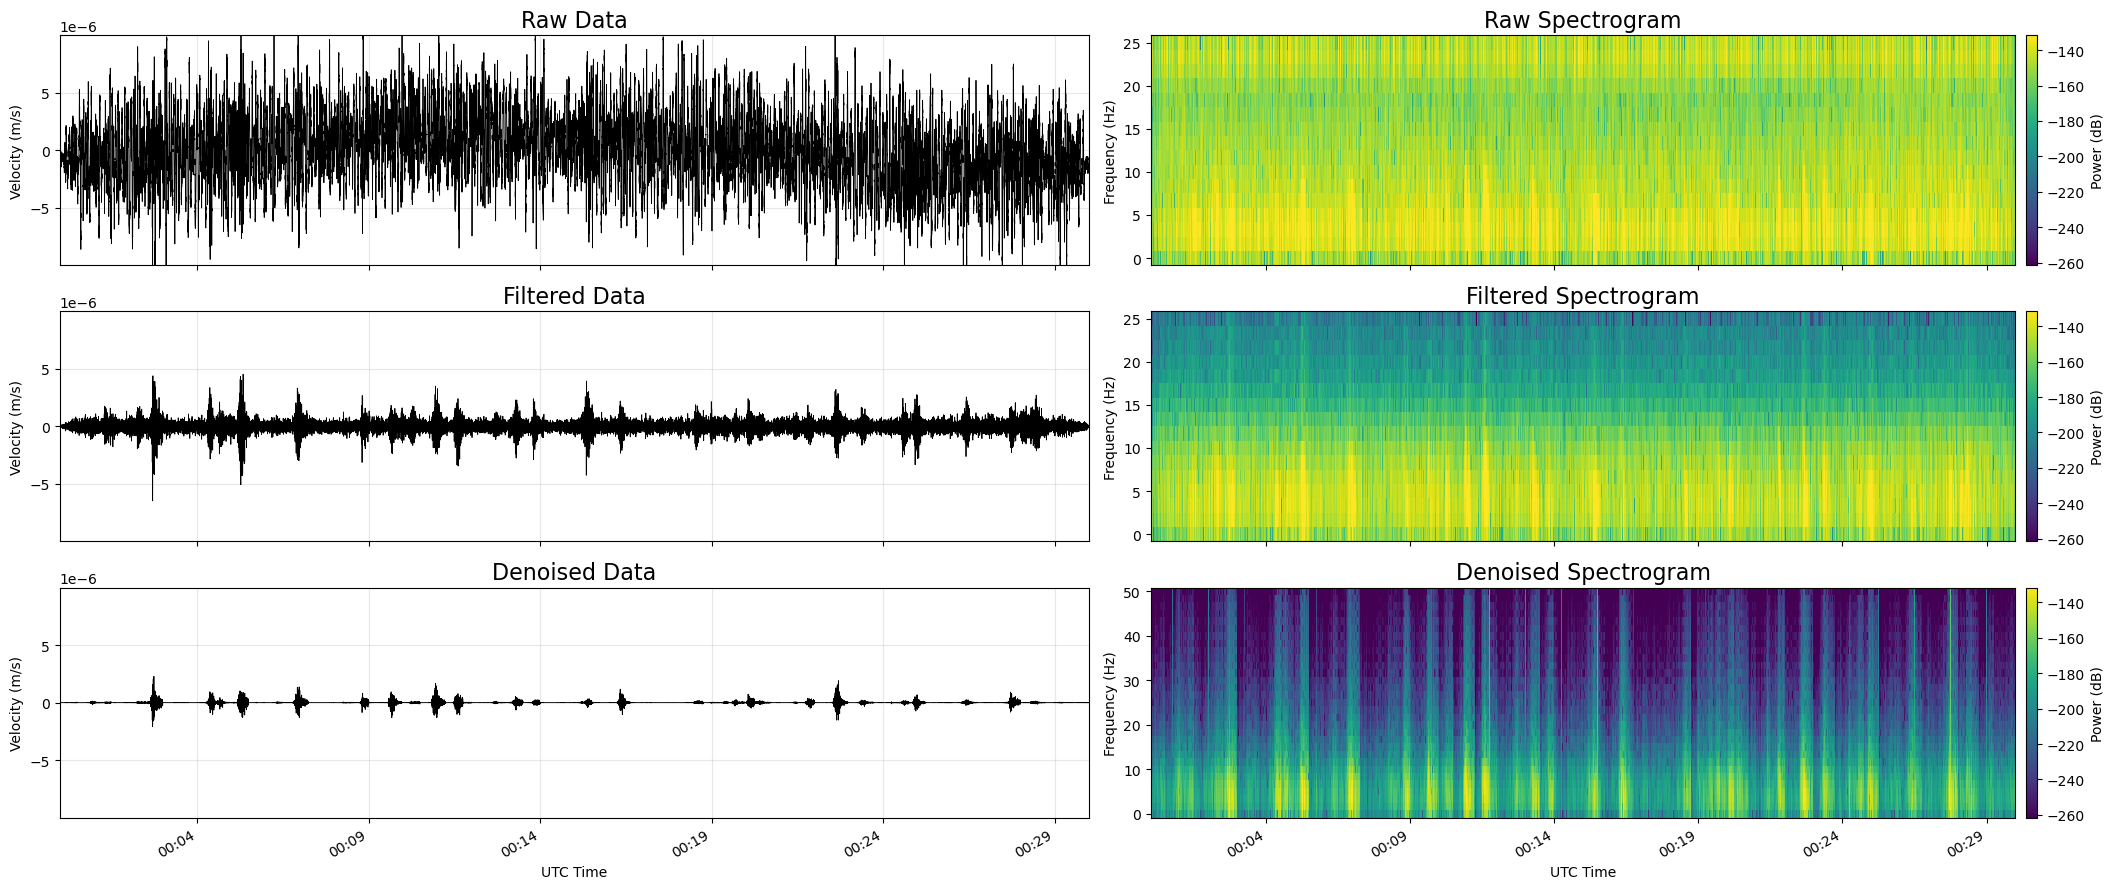

In [44]:
# plot raw / filtered / denoised waveforms + spectrograms

times_raw = raw_trace.times("matplotlib")
times_filtered = filtered_full_trace.times("matplotlib")
times_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

# spectrogram settings taken from DeepDenoiser's own STFT
# (annotate_window_pre: scipy.signal.stft(..., nperseg=30, nfft=60), Hann window, 50% overlap)
DD_FS = model.sampling_rate        # 100 Hz
DD_NPERSEG = 30                    # samples at 100 Hz -> 0.3 s
DD_NFFT = 60                       # samples at 100 Hz -> 0.6 s, 1.67 Hz bins
DD_NPERSEG_S = DD_NPERSEG / DD_FS
DD_NFFT_S = DD_NFFT / DD_FS

def compute_spectrogram(tr):
    fs = tr.stats.sampling_rate
    nperseg = int(round(DD_NPERSEG_S * fs))     # 30 @ 100 Hz, 15 @ 50 Hz
    nfft = int(round(DD_NFFT_S * fs))           # 60 @ 100 Hz, 30 @ 50 Hz
    noverlap = nperseg // 2                     # scipy.stft default overlap
    f, t, Sxx = signal.spectrogram(
        tr.data, fs=fs, window="hann",          # spectrogram() defaults to Tukey; stft() uses Hann
        nperseg=nperseg, noverlap=noverlap, nfft=nfft,
        scaling="density", mode="psd"
    )
    t_mpl = tr.stats.starttime.matplotlib_date + t / 86400.0
    Sdb = 10 * np.log10(Sxx + 1e-30)
    return f, t_mpl, Sdb

specs = [
    compute_spectrogram(raw_trace),
    compute_spectrogram(filtered_full_trace),
    compute_spectrogram(denoised_full_trace),
]

# shared color scale so the three spectrograms are directly comparable
all_db = np.concatenate([s[2].ravel() for s in specs])
vmin, vmax = np.percentile(all_db, [5, 99])

fig, axes = plt.subplots(3, 2, figsize=(22, 9), sharex=True)

# waveforms
axes[0, 0].plot(times_raw, raw_trace.data, linewidth=0.6, color="black")
axes[0, 0].set_title("Raw Data", fontsize=16)

axes[1, 0].plot(times_filtered, filtered_full_trace.data, linewidth=0.6, color="black")
axes[1, 0].set_title("Filtered Data", fontsize=16)

axes[2, 0].plot(times_denoised, denoised_full_trace.data, linewidth=0.6, color="black")
axes[2, 0].set_title("Denoised Data", fontsize=16)
axes[2, 0].set_xlabel("UTC Time")

for i in range(3):
    ax = axes[i, 0]
    ax.set_ylabel("Velocity (m/s)")
    ax.set_ylim(waveform_ylim)
    ax.set_yticks(waveform_yticks)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
    ax.grid(True, alpha=0.3)

# spectrograms
titles = ["Raw Spectrogram", "Filtered Spectrogram", "Denoised Spectrogram"]
for i, ((f, t_mpl, Sdb), title) in enumerate(zip(specs, titles)):
    ax = axes[i, 1]
    pcm = ax.pcolormesh(t_mpl, f, Sdb, shading="auto", cmap="viridis",
                        vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel("Frequency (Hz)")
    fig.colorbar(pcm, ax=ax, label="Power (dB)", pad=0.01)

axes[2, 1].set_xlabel("UTC Time")

for ax in axes.ravel():
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Model sampling rate: 100 Hz
Inference window: 30.0 seconds
overlap=1500: overlap=15.0 s, stride=15.0 s, output fs=100.0 Hz
overlap=1800: overlap=18.0 s, stride=12.0 s, output fs=100.0 Hz
overlap=2000: overlap=20.0 s, stride=10.0 s, output fs=100.0 Hz
overlap=2500: overlap=25.0 s, stride=5.0 s, output fs=100.0 Hz


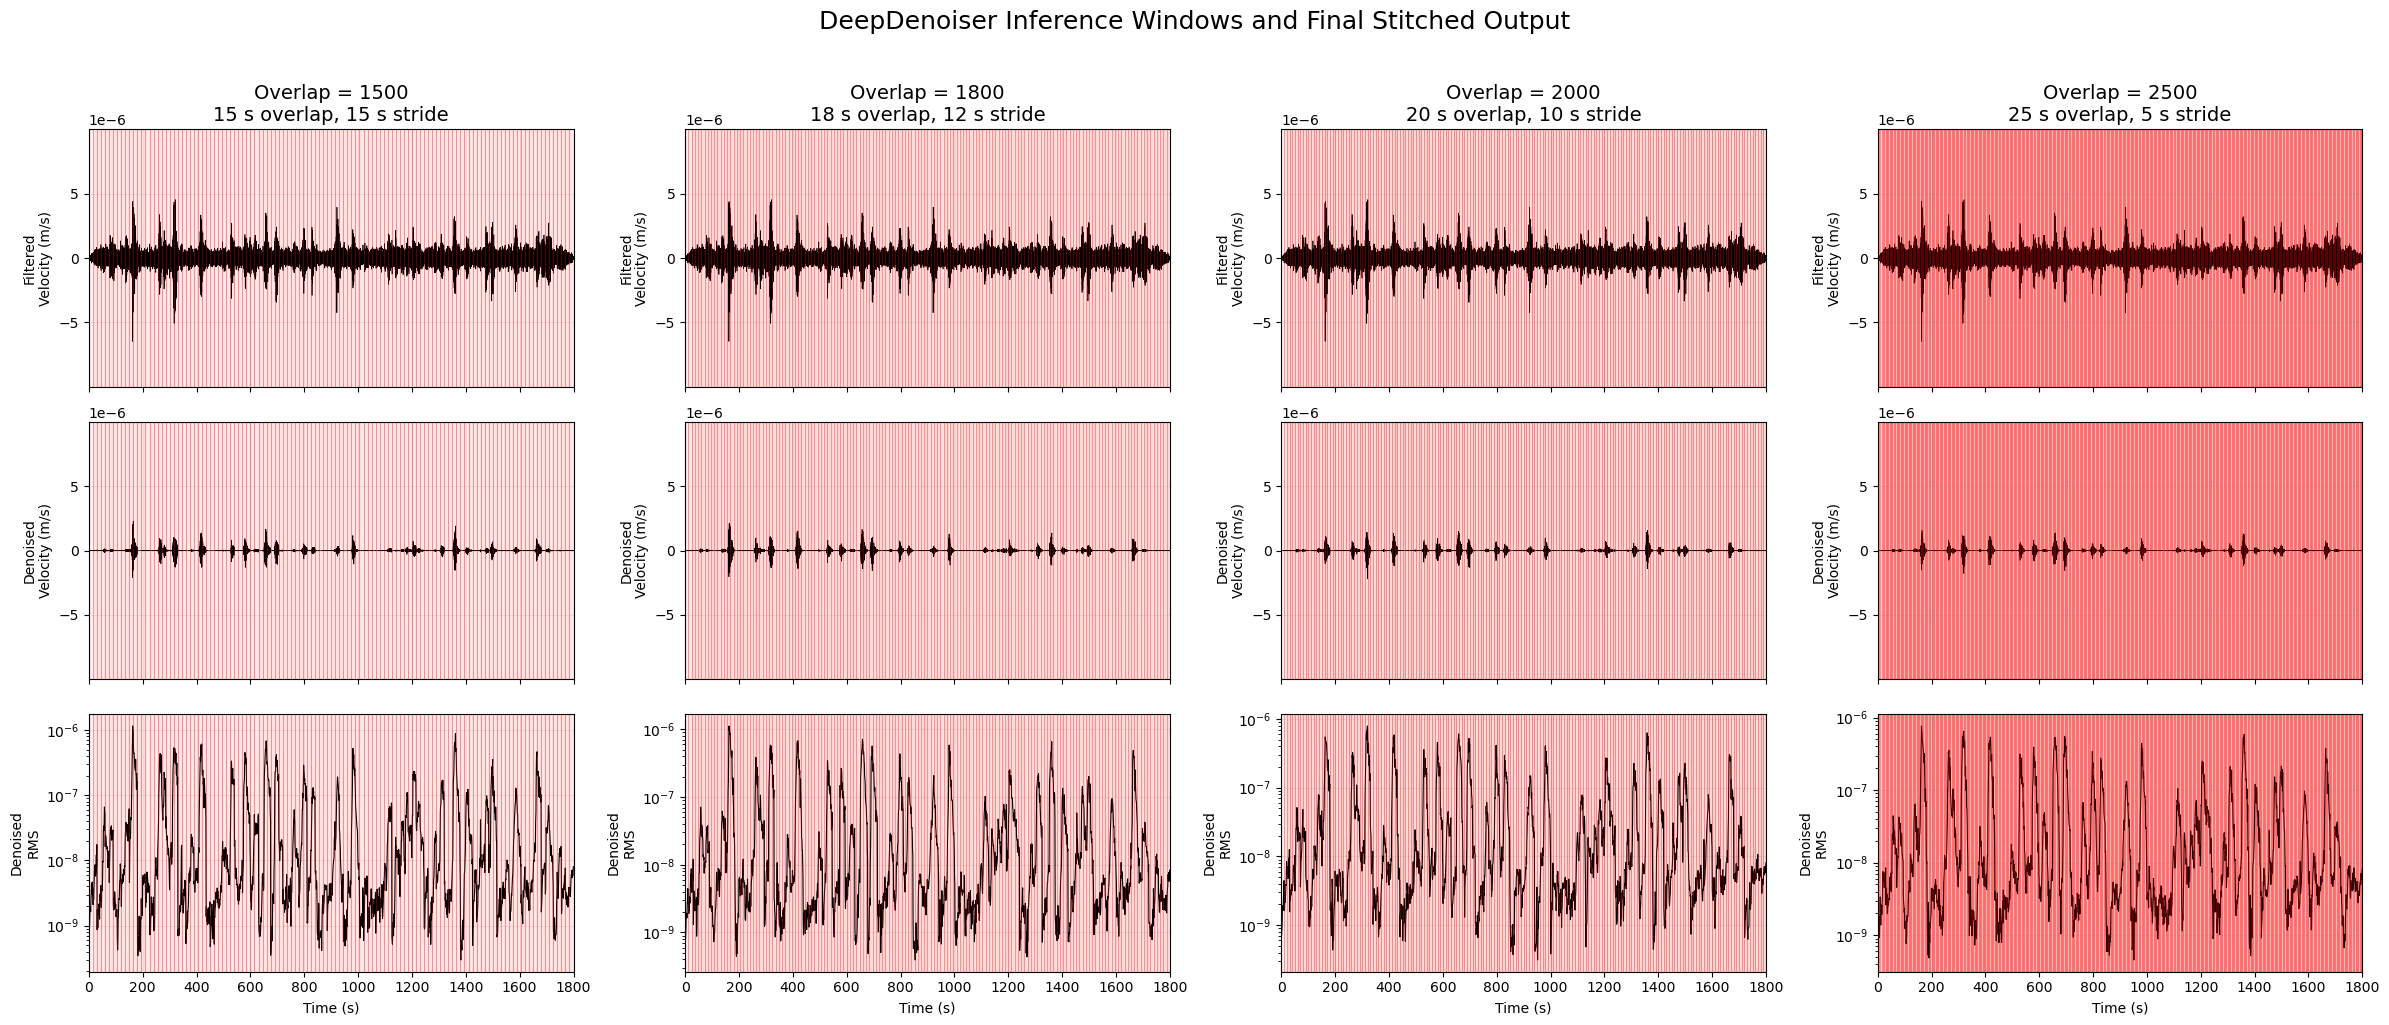

In [73]:
# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

overlaps = [1500, 1800, 2000, 2500]

model_fs = model.sampling_rate       # DeepDenoiser = 100 Hz
in_samples = model.in_samples        # DeepDenoiser = 3000 samples
window_seconds = in_samples / model_fs

print(f"Model sampling rate: {model_fs} Hz")
print(f"Inference window: {window_seconds:.1f} seconds")

# ------------------------------------------------------------
# Run the denoiser for each overlap
# ------------------------------------------------------------

runs = {}

for ov in overlaps:
    denoised = model.annotate(
        Stream([filtered_full_trace.copy()]),
        overlap=ov
    )[0]

    runs[ov] = denoised

    stride_samples = in_samples - ov
    stride_seconds = stride_samples / model_fs

    print(
        f"overlap={ov}: "
        f"overlap={ov/model_fs:.1f} s, "
        f"stride={stride_seconds:.1f} s, "
        f"output fs={denoised.stats.sampling_rate} Hz"
    )


# ------------------------------------------------------------
# Helper: RMS
# ------------------------------------------------------------

def running_rms(data, fs, window_seconds=1.0):
    """Calculate RMS in non-overlapping windows."""
    
    n = int(window_seconds * fs)
    n_windows = len(data) // n
    
    trimmed = data[:n_windows * n]
    chunks = trimmed.reshape(n_windows, n)
    
    rms = np.sqrt(np.mean(chunks**2, axis=1))
    times = (np.arange(n_windows) + 0.5) * window_seconds
    
    return times, rms


# ------------------------------------------------------------
# Time arrays
# ------------------------------------------------------------

filtered_fs = filtered_full_trace.stats.sampling_rate

filtered_time = (
    np.arange(len(filtered_full_trace.data)) / filtered_fs
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    len(overlaps),
    figsize=(24, 10),
    sharex="col"
)

for col, ov in enumerate(overlaps):

    denoised = runs[ov]
    denoised_fs = denoised.stats.sampling_rate

    denoised_time = (
        np.arange(len(denoised.data)) / denoised_fs
    )

    # --------------------------------------------------------
    # Actual inference-window geometry
    # --------------------------------------------------------

    stride_seconds = (
        (in_samples - ov) / model_fs
    )

    total_duration = min(
        filtered_time[-1],
        denoised_time[-1]
    )

    window_starts = np.arange(
        0,
        total_duration,
        stride_seconds
    )

    window_ends = window_starts + window_seconds

    # --------------------------------------------------------
    # Top: filtered waveform
    # --------------------------------------------------------

    ax = axes[0, col]

    ax.plot(
        filtered_time,
        filtered_full_trace.data,
        linewidth=0.5,
        color="black"
    )

    ax.set_title(
        f"Overlap = {ov}\n"
        f"{ov/model_fs:.0f} s overlap, "
        f"{stride_seconds:.0f} s stride",
        fontsize=14
    )

    ax.set_ylabel("Filtered\nVelocity (m/s)")

    ax.set_ylim(-10e-6, 10e-6)
    ax.set_yticks([-5e-6, 0, 5e-6])
    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-6, -6)
    )

    ax.grid(True, alpha=0.25)

    # --------------------------------------------------------
    # Middle: final stitched denoised waveform
    # --------------------------------------------------------

    ax = axes[1, col]

    ax.plot(
        denoised_time,
        denoised.data,
        linewidth=0.5,
        color="black"
    )

    ax.set_ylabel("Denoised\nVelocity (m/s)")

    ax.set_ylim(-10e-6, 10e-6)
    ax.set_yticks([-5e-6, 0, 5e-6])
    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-6, -6)
    )

    ax.grid(True, alpha=0.25)

    # --------------------------------------------------------
    # Bottom: denoised RMS
    # --------------------------------------------------------

    ax = axes[2, col]

    rms_time, rms = running_rms(
        denoised.data,
        denoised_fs,
        window_seconds=1.0
    )

    ax.semilogy(
        rms_time,
        rms + 1e-14,
        linewidth=0.8,
        color="black"
    )

    ax.set_ylabel("Denoised\nRMS")

    ax.grid(True, alpha=0.25)

    # --------------------------------------------------------
    # Overlay actual inference-window boundaries
    # --------------------------------------------------------

    for start, end in zip(window_starts, window_ends):

        # Window start
        for row in range(3):
            axes[row, col].axvline(
                start,
                color="red",
                alpha=0.35,
                linewidth=0.8
            )

        # Light shading showing the full 30-s window
        for row in range(3):
            axes[row, col].axvspan(
                start,
                min(end, total_duration),
                color="red",
                alpha=0.04
            )

    axes[2, col].set_xlabel("Time (s)")


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

for ax in axes.ravel():
    ax.set_xlim(
        0,
        min(
            filtered_time[-1],
            max(runs[ov].times()[-1] if hasattr(runs[ov], "times") else
                len(runs[ov].data) / runs[ov].stats.sampling_rate
                for ov in overlaps)
        )
    )

plt.suptitle(
    "DeepDenoiser Inference Windows and Final Stitched Output",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

Model sampling rate: 100 Hz
Model inference window: 30.0 s
overlap=1500: overlap=15.0 s, stride=15.0 s, output fs=100.0 Hz
overlap=1800: overlap=18.0 s, stride=12.0 s, output fs=100.0 Hz
overlap=2000: overlap=20.0 s, stride=10.0 s, output fs=100.0 Hz
overlap=2500: overlap=25.0 s, stride=5.0 s, output fs=100.0 Hz


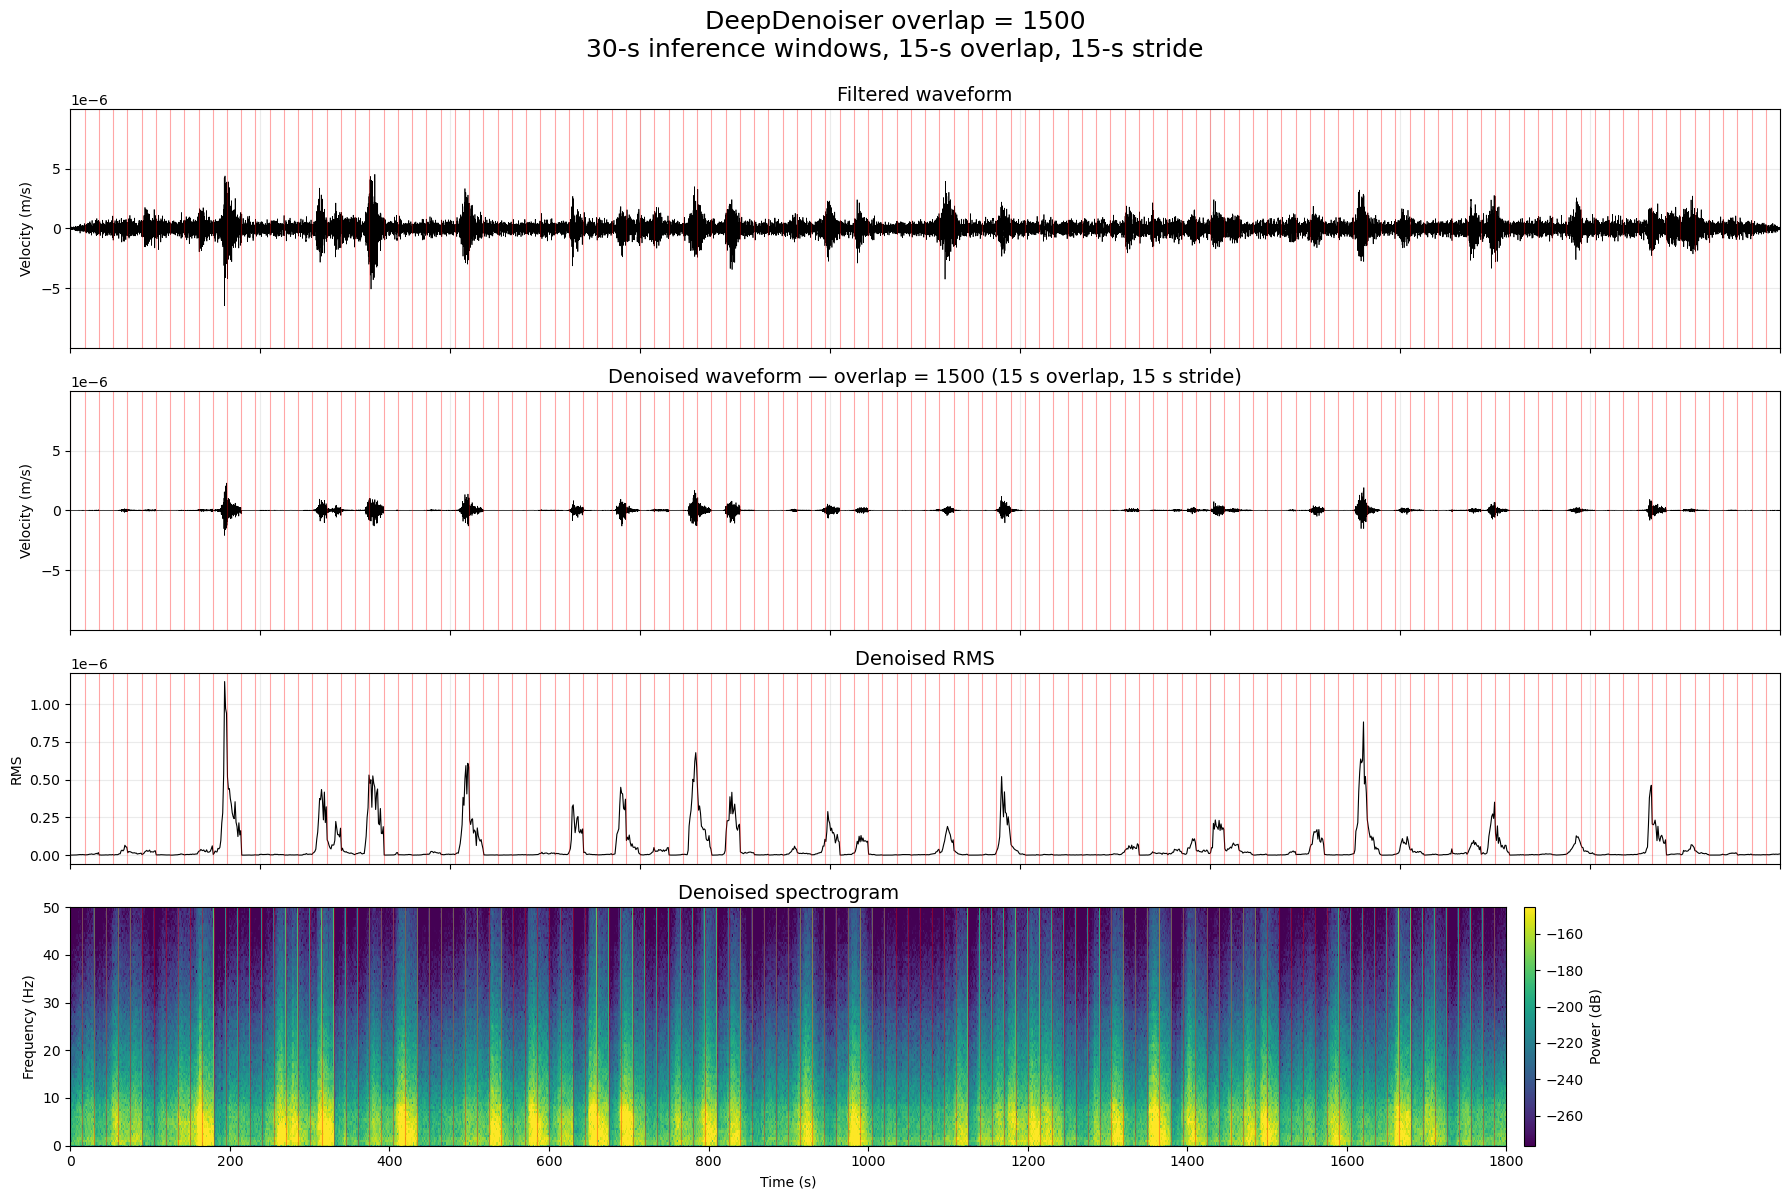

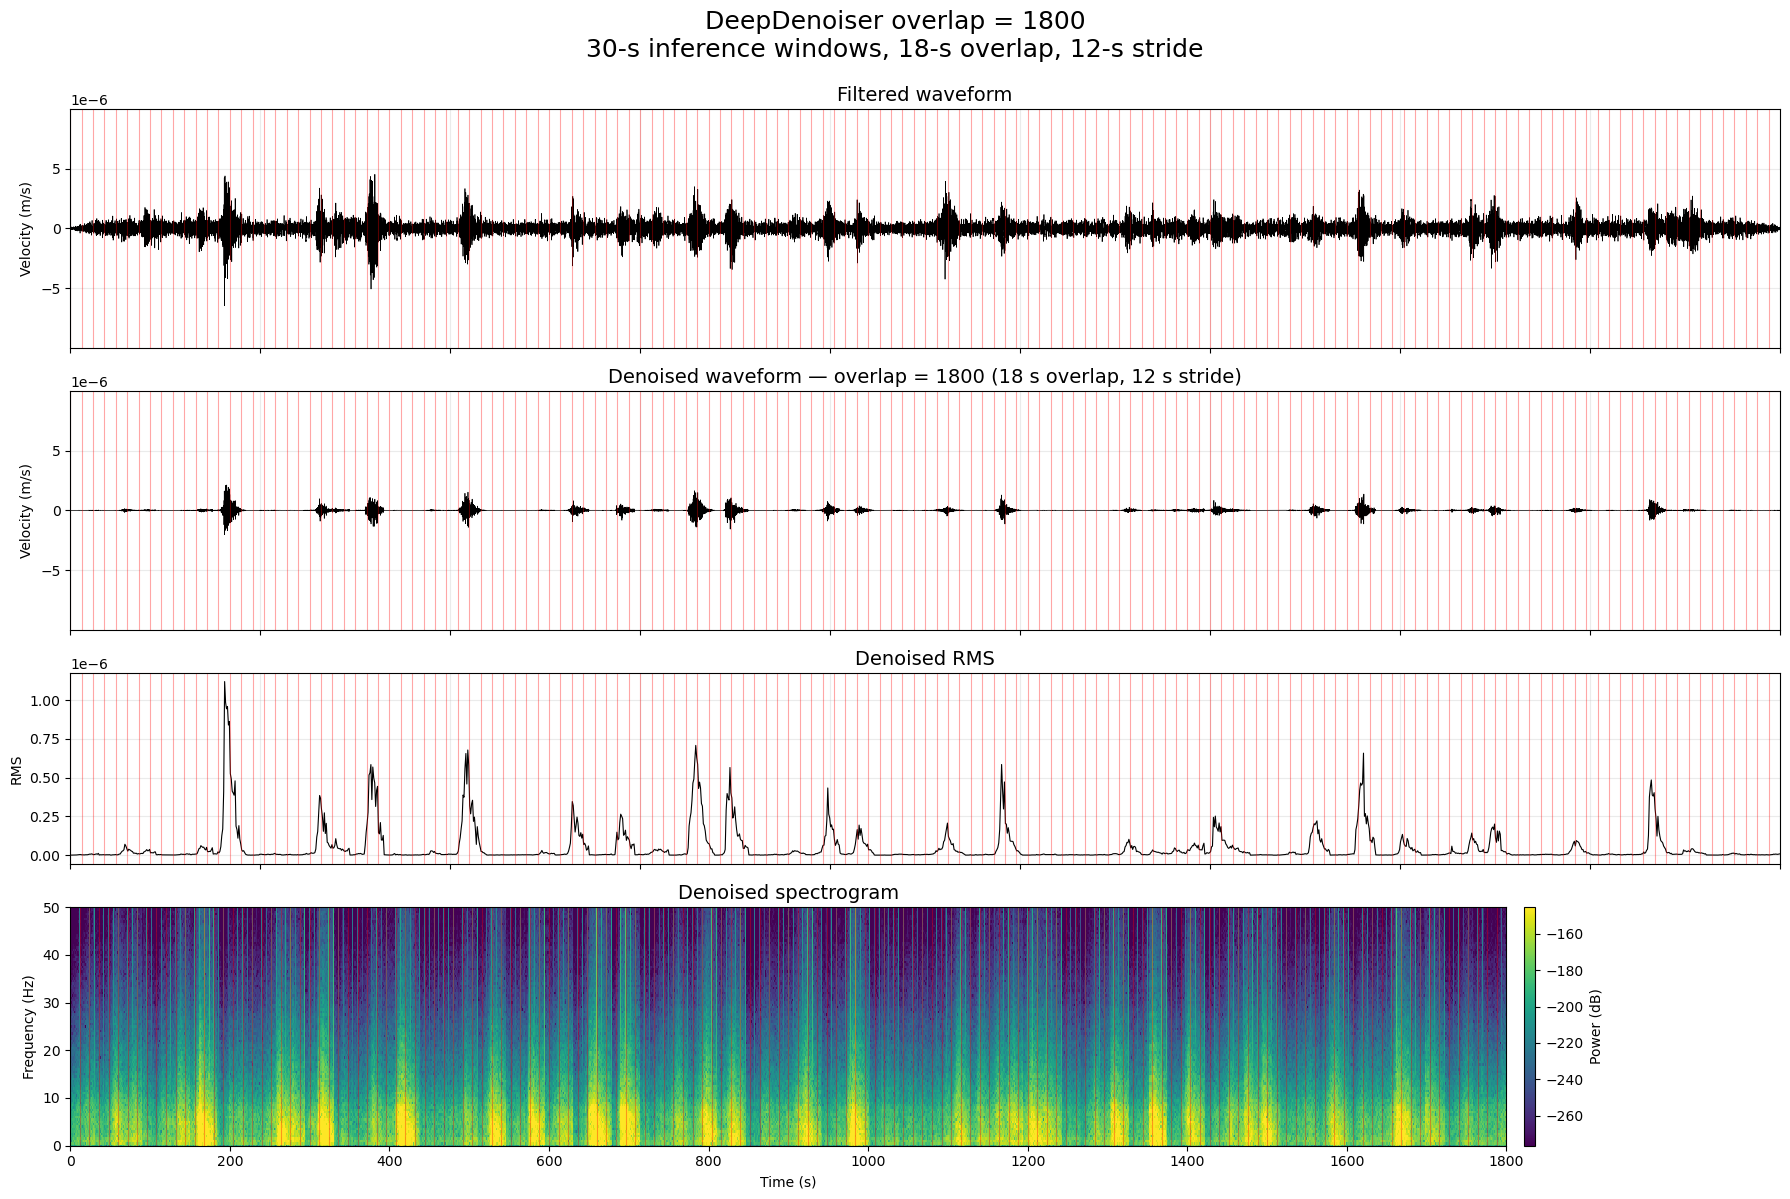

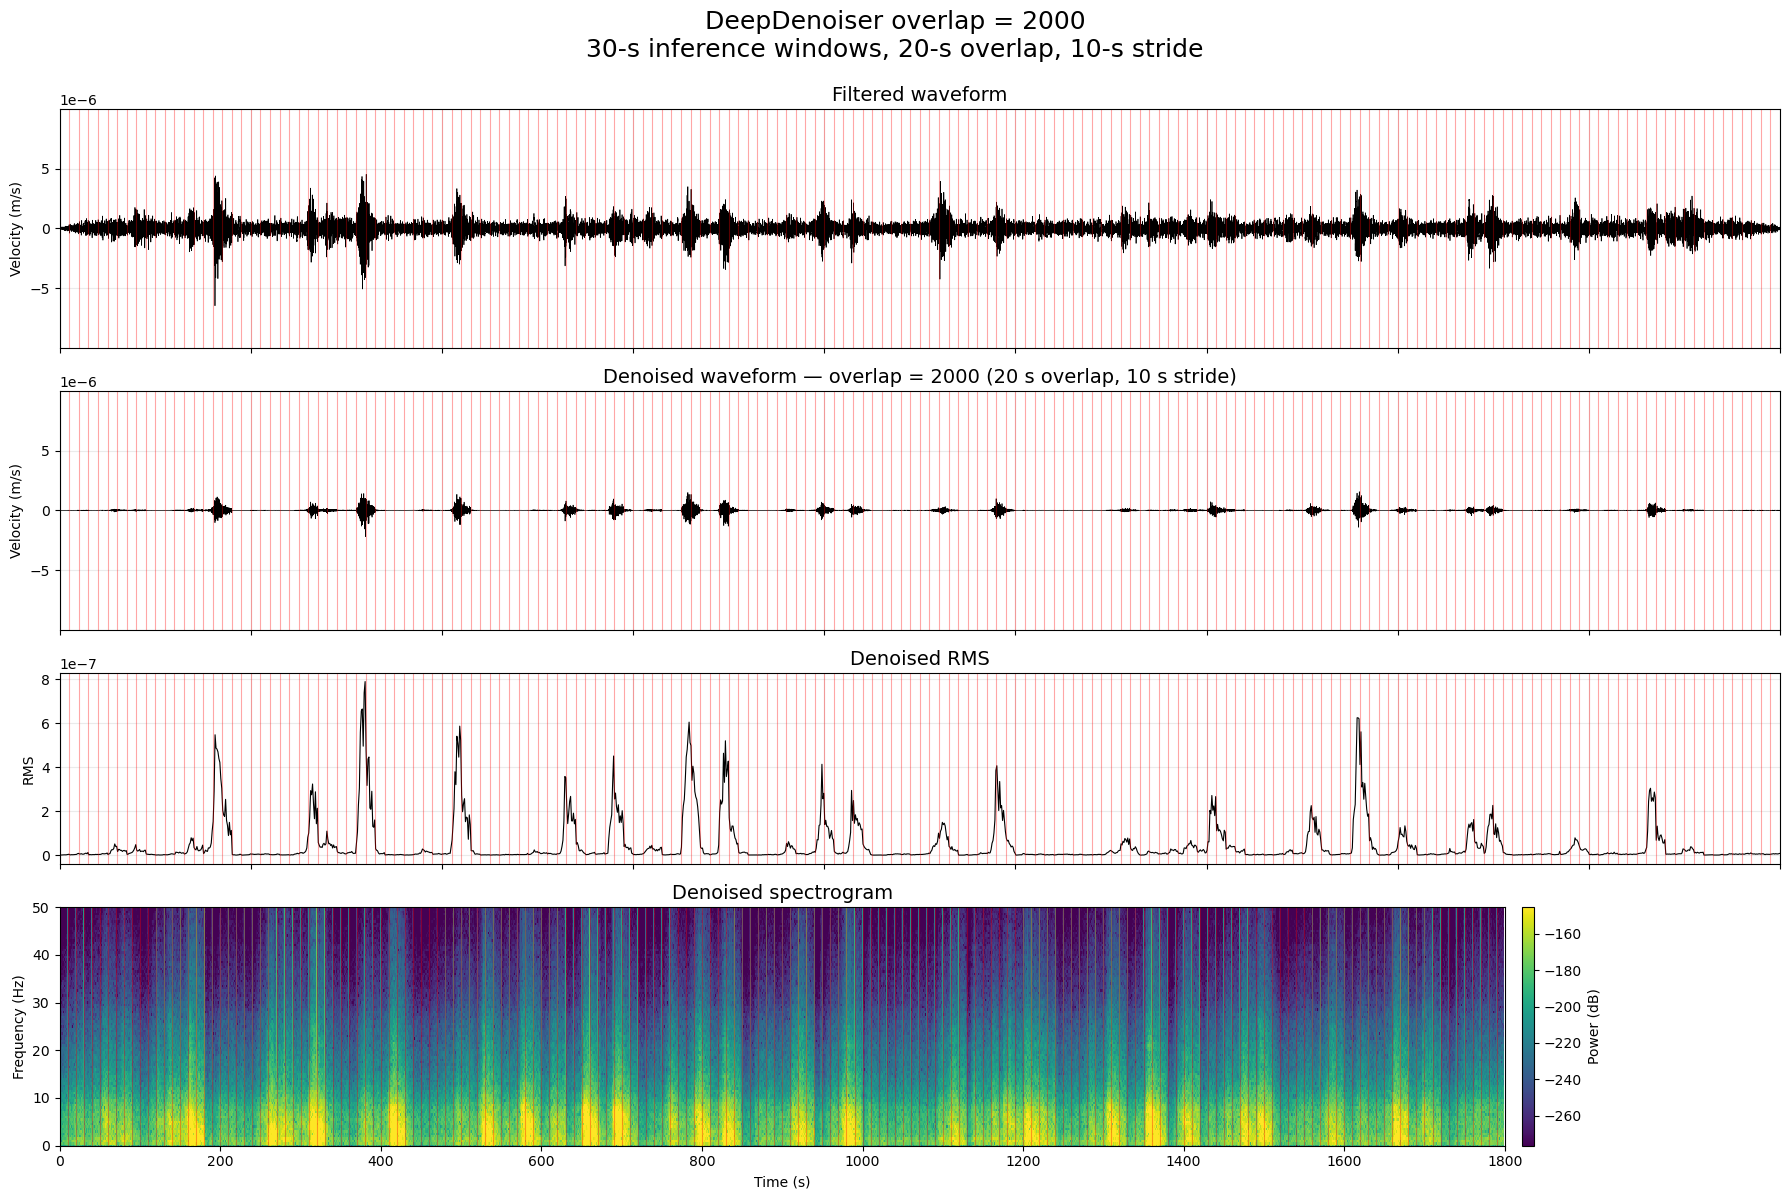

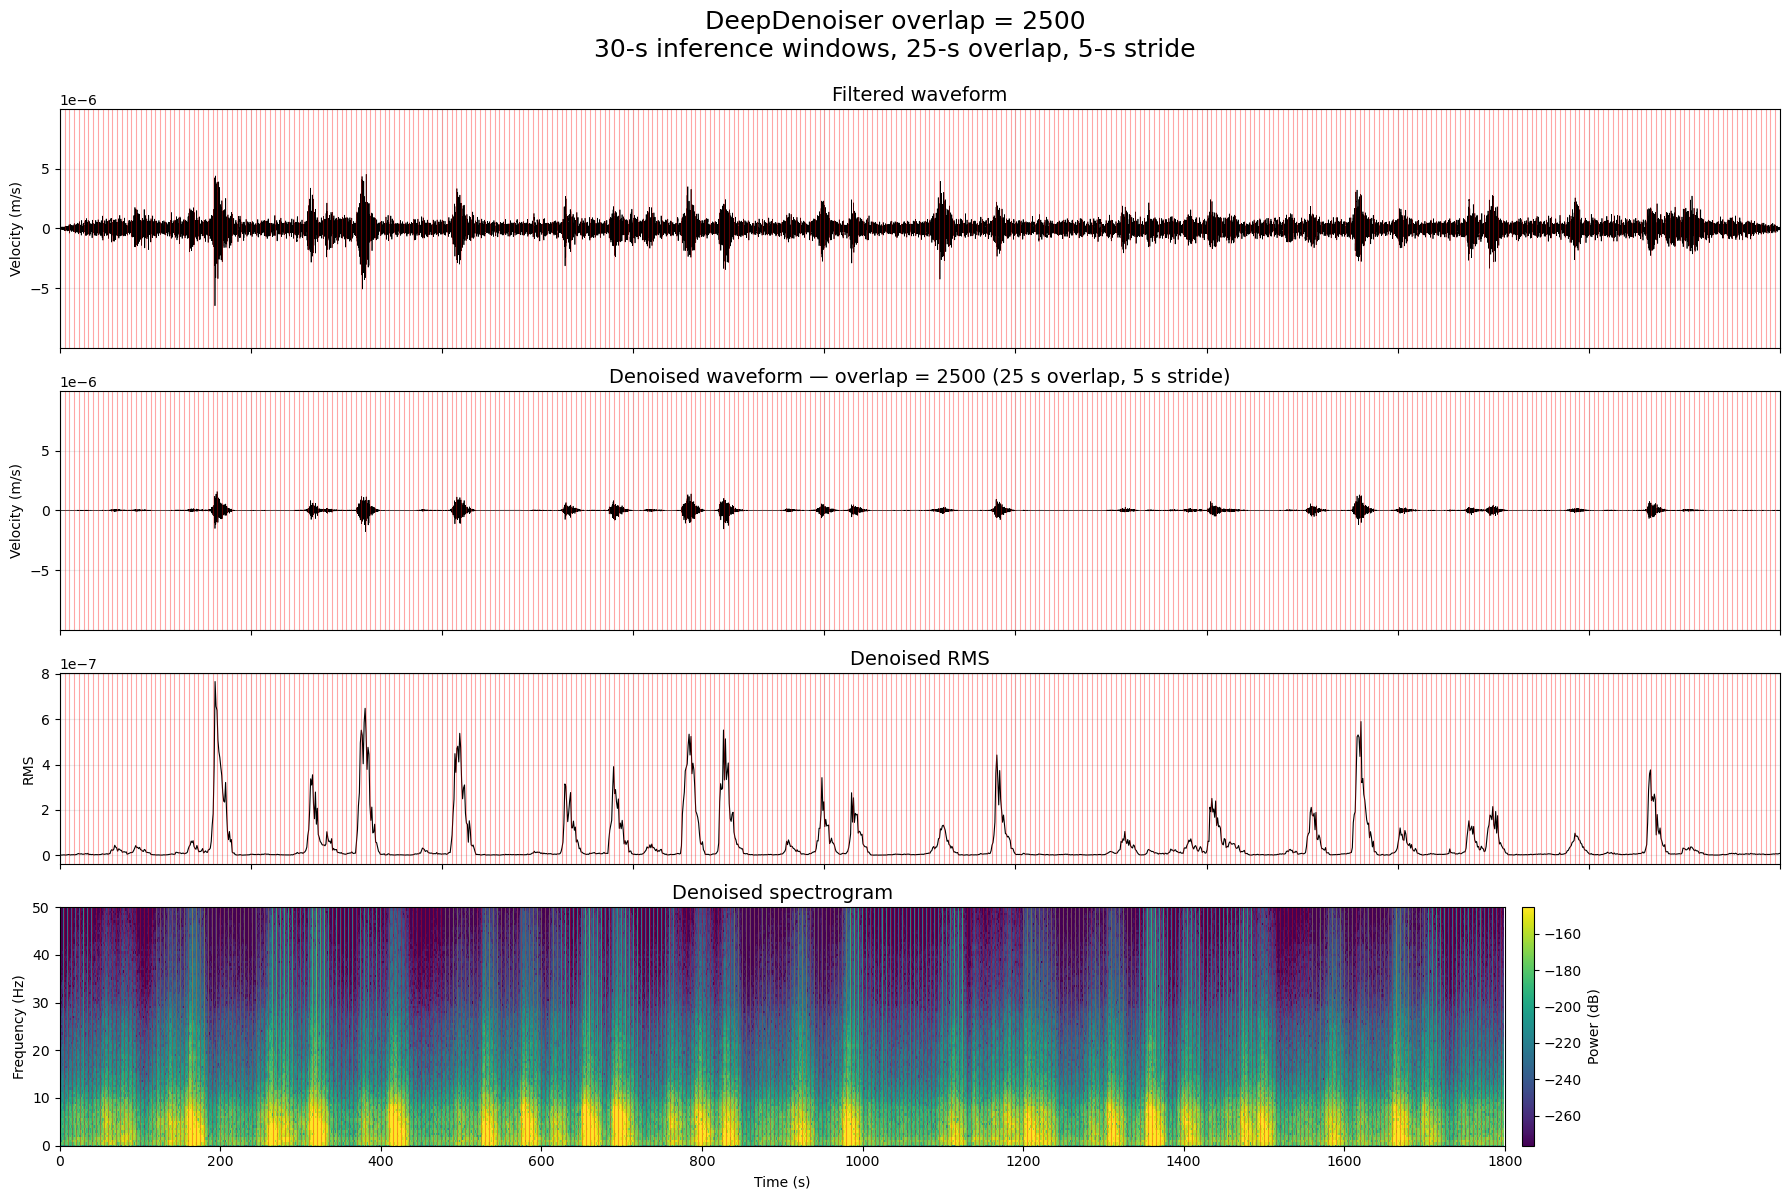

In [45]:
# %% Compare DeepDenoiser overlap settings
#
# For each overlap:
#   1. Filtered waveform
#   2. Denoised waveform
#   3. Denoised RMS
#   4. Denoised spectrogram
#
# Red vertical lines/shading = actual DeepDenoiser
# 30-second inference windows.
#
# DeepDenoiser:
#   in_samples = 3000
#   sampling_rate = 100 Hz
#   inference window = 30 seconds
#
# Overlap values:
#   1500 -> 15 s overlap, 15 s stride
#   1800 -> 18 s overlap, 12 s stride
#   2000 -> 20 s overlap, 10 s stride
#   2500 -> 25 s overlap,  5 s stride


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from obspy import Stream


# ============================================================
# Settings
# ============================================================

overlaps = [1500, 1800, 2000, 2500]

# Waveform limits
waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

# RMS calculation
rms_window_seconds = 1.0

# Spectrogram settings
#
# These control the time-frequency visualization only.
# They are NOT the DeepDenoiser inference windows.
#
# The actual DeepDenoiser windows are overlaid separately.
spec_window_seconds = 2.0
spec_overlap = 0.5


# ============================================================
# DeepDenoiser window information
# ============================================================

model_fs = model.sampling_rate
in_samples = model.in_samples

inference_window_seconds = (
    in_samples / model_fs
)

print(f"Model sampling rate: {model_fs} Hz")
print(f"Model inference window: {inference_window_seconds:.1f} s")


# ============================================================
# Run DeepDenoiser for each overlap
# ============================================================

runs = {}

for ov in overlaps:

    denoised = model.annotate(
        Stream([filtered_full_trace.copy()]),
        overlap=ov
    )[0]

    runs[ov] = denoised

    stride_samples = in_samples - ov
    stride_seconds = stride_samples / model_fs

    print(
        f"overlap={ov}: "
        f"overlap={ov/model_fs:.1f} s, "
        f"stride={stride_seconds:.1f} s, "
        f"output fs={denoised.stats.sampling_rate} Hz"
    )


# ============================================================
# Helper: calculate RMS
# ============================================================

def calculate_rms(data, fs, window_seconds=1.0):

    n = int(window_seconds * fs)

    n_windows = len(data) // n

    trimmed = data[:n_windows * n]

    chunks = trimmed.reshape(
        n_windows,
        n
    )

    rms = np.sqrt(
        np.mean(chunks**2, axis=1)
    )

    # Center each RMS value in its window
    times = (
        np.arange(n_windows) + 0.5
    ) * window_seconds

    return times, rms


# ============================================================
# Helper: calculate spectrogram
# ============================================================

def calculate_spectrogram(
    trace,
    window_seconds=2.0,
    overlap=0.5
):

    fs = trace.stats.sampling_rate

    nperseg = int(
        window_seconds * fs
    )

    noverlap = int(
        nperseg * overlap
    )

    f, t, Sxx = signal.spectrogram(
        trace.data,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="density",
        mode="psd"
    )

    # Convert power to dB
    Sdb = 10 * np.log10(
        Sxx + 1e-30
    )

    return f, t, Sdb


# ============================================================
# Filtered waveform time axis
# ============================================================

filtered_fs = (
    filtered_full_trace.stats.sampling_rate
)

filtered_time = (
    np.arange(
        len(filtered_full_trace.data)
    )
    / filtered_fs
)


# ============================================================
# Calculate all denoised spectrograms
# ============================================================

denoised_specs = {}

for ov in overlaps:

    f, t, Sdb = calculate_spectrogram(
        runs[ov],
        window_seconds=spec_window_seconds,
        overlap=spec_overlap
    )

    denoised_specs[ov] = (
        f,
        t,
        Sdb
    )


# ============================================================
# Use the SAME color scale for all denoised spectrograms
#
# This lets us compare the overlap settings directly.
# ============================================================

all_values = np.concatenate(
    [
        denoised_specs[ov][2].ravel()
        for ov in overlaps
    ]
)

spec_vmin, spec_vmax = np.percentile(
    all_values,
    [5, 99]
)


# ============================================================
# Create one figure for each overlap
# ============================================================

for ov in overlaps:

    denoised = runs[ov]

    denoised_fs = (
        denoised.stats.sampling_rate
    )

    denoised_time = (
        np.arange(
            len(denoised.data)
        )
        / denoised_fs
    )


    # --------------------------------------------------------
    # RMS
    # --------------------------------------------------------

    rms_time, rms = calculate_rms(
        denoised.data,
        denoised_fs,
        window_seconds=rms_window_seconds
    )


    # --------------------------------------------------------
    # Denoised spectrogram
    # --------------------------------------------------------

    denoised_f, denoised_t, denoised_Sdb = (
        denoised_specs[ov]
    )


    # --------------------------------------------------------
    # Inference-window geometry
    # --------------------------------------------------------

    stride_seconds = (
        (in_samples - ov)
        / model_fs
    )

    total_duration = min(
        filtered_time[-1],
        denoised_time[-1]
    )

    # Start of every DeepDenoiser inference window
    window_starts = np.arange(
        0,
        total_duration,
        stride_seconds
    )

    # End of every 30-second inference window
    window_ends = (
        window_starts
        + inference_window_seconds
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(18, 12),
        sharex=True,
        gridspec_kw={
            "height_ratios": [
                1,
                1,
                0.8,
                1
            ]
        }
    )


    # ========================================================
    # 1. Filtered waveform
    # ========================================================

    ax = axes[0]

    ax.plot(
        filtered_time,
        filtered_full_trace.data,
        linewidth=0.5,
        color="black"
    )

    ax.set_title(
        "Filtered waveform",
        fontsize=14
    )

    ax.set_ylabel(
        "Velocity (m/s)"
    )

    ax.set_ylim(
        waveform_ylim
    )

    ax.set_yticks(
        waveform_yticks
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-6, -6)
    )

    ax.grid(
        True,
        alpha=0.25
    )


    # ========================================================
    # 2. Denoised waveform
    # ========================================================

    ax = axes[1]

    ax.plot(
        denoised_time,
        denoised.data,
        linewidth=0.5,
        color="black"
    )

    ax.set_title(
        f"Denoised waveform — "
        f"overlap = {ov} "
        f"({ov/model_fs:.0f} s overlap, "
        f"{stride_seconds:.0f} s stride)",
        fontsize=14
    )

    ax.set_ylabel(
        "Velocity (m/s)"
    )

    ax.set_ylim(
        waveform_ylim
    )

    ax.set_yticks(
        waveform_yticks
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-6, -6)
    )

    ax.grid(
        True,
        alpha=0.25
    )


    # ========================================================
    # 3. Denoised RMS
    # ========================================================

    ax = axes[2]

    ax.plot(
        rms_time,
        rms,
        linewidth=0.8,
        color="black"
    )

    ax.set_title(
        "Denoised RMS",
        fontsize=14
    )

    ax.set_ylabel(
        "RMS"
    )

    ax.grid(
        True,
        alpha=0.25
    )


    # ========================================================
    # 4. Denoised spectrogram
    # ========================================================

    ax = axes[3]

    pcm = ax.pcolormesh(
        denoised_t,
        denoised_f,
        denoised_Sdb,
        shading="auto",
        vmin=spec_vmin,
        vmax=spec_vmax
    )

    ax.set_title(
        "Denoised spectrogram",
        fontsize=14
    )

    ax.set_ylabel(
        "Frequency (Hz)"
    )

    ax.set_xlabel(
        "Time (s)"
    )

    ax.set_ylim(
        0,
        model_fs / 2
    )

    fig.colorbar(
        pcm,
        ax=ax,
        label="Power (dB)",
        pad=0.01
    )


    # ========================================================
    # Overlay ACTUAL DeepDenoiser inference windows
    #
    # These are drawn on ALL FOUR panels.
    #
    # Red vertical line:
    #     start of a DD inference window
    #
    # Light red shading:
    #     full 30-second DD inference window
    # ========================================================

    for start, end in zip(
        window_starts,
        window_ends
    ):

        end = min(
            end,
            total_duration
        )

        for ax in axes:

            # DD inference-window start
            ax.axvline(
                start,
                color="red",
                alpha=0.35,
                linewidth=0.8
            )


    # ========================================================
    # Common formatting
    # ========================================================

    for ax in axes:

        ax.set_xlim(
            0,
            total_duration
        )

        ax.margins(
            x=0
        )


    # ========================================================
    # Figure title
    # ========================================================

    fig.suptitle(
        f"DeepDenoiser overlap = {ov}\n"
        f"30-s inference windows, "
        f"{ov/model_fs:.0f}-s overlap, "
        f"{stride_seconds:.0f}-s stride",
        fontsize=18,
        y=0.995
    )

    plt.tight_layout()

    plt.show()

Filtered: 19 events
Any NaNs (filtered): False
overlap=1500: 21 denoised events
    Any NaNs (denoised): False


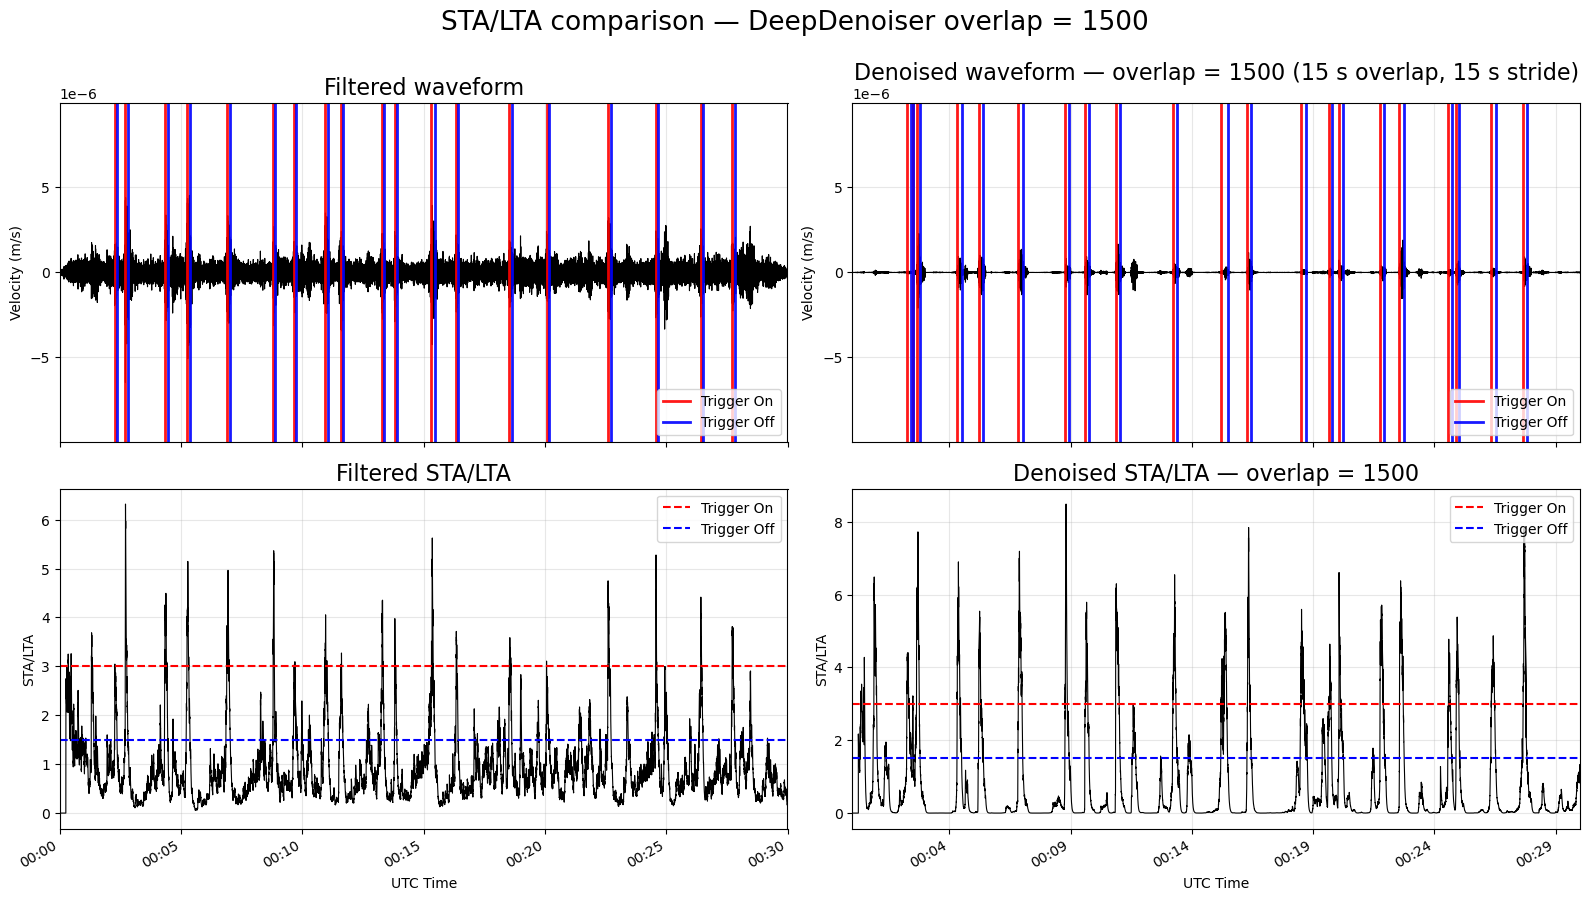

overlap=1800: 21 denoised events
    Any NaNs (denoised): False


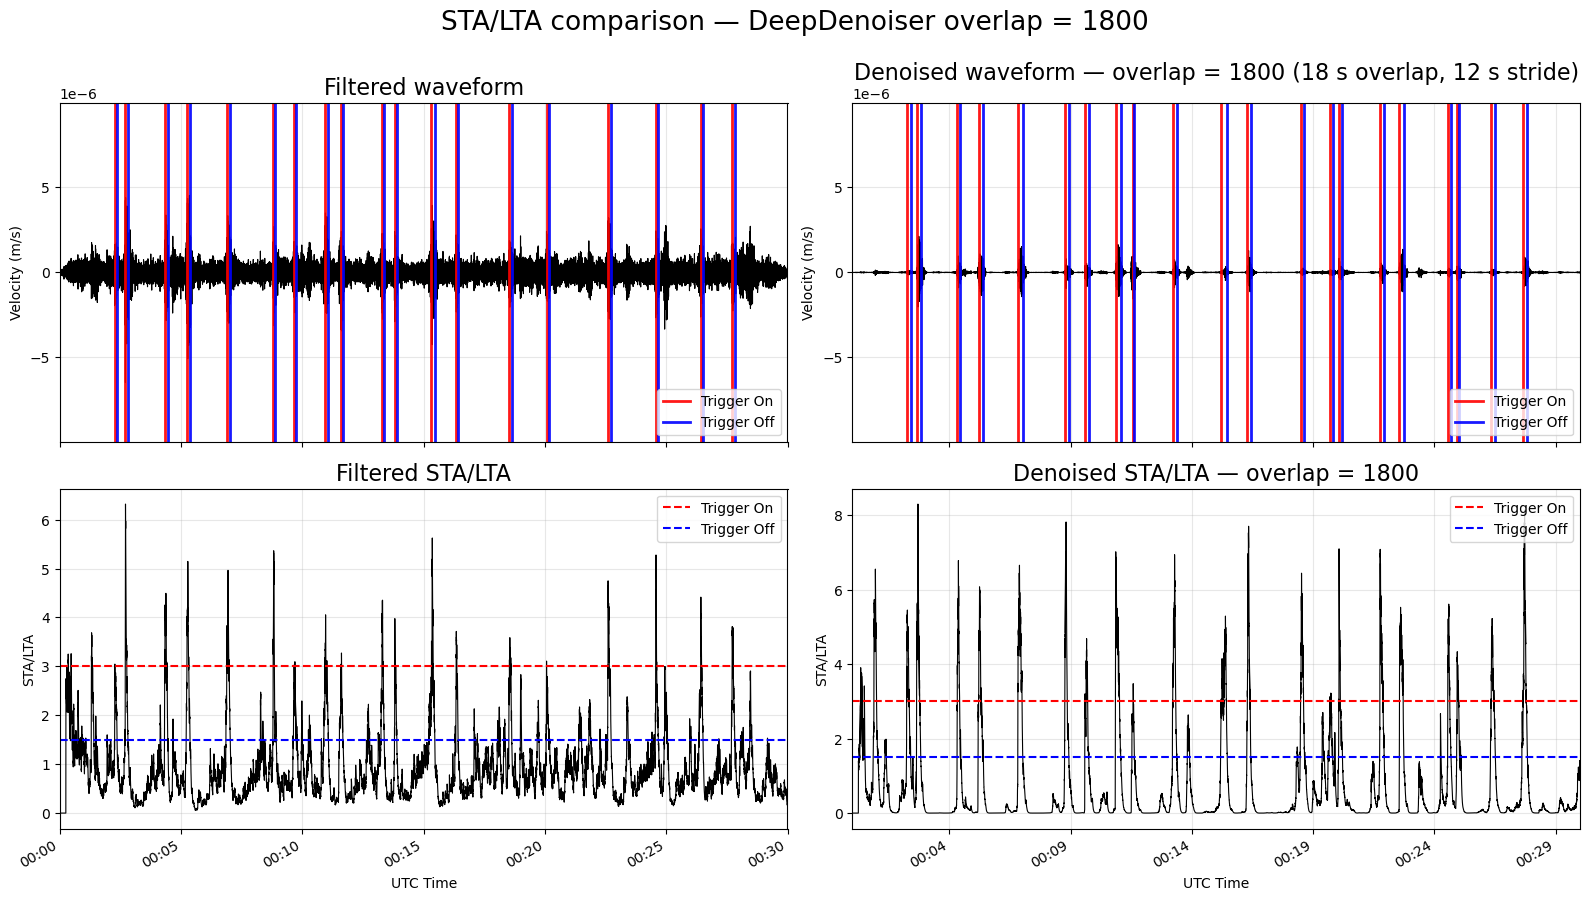

overlap=2000: 23 denoised events
    Any NaNs (denoised): False


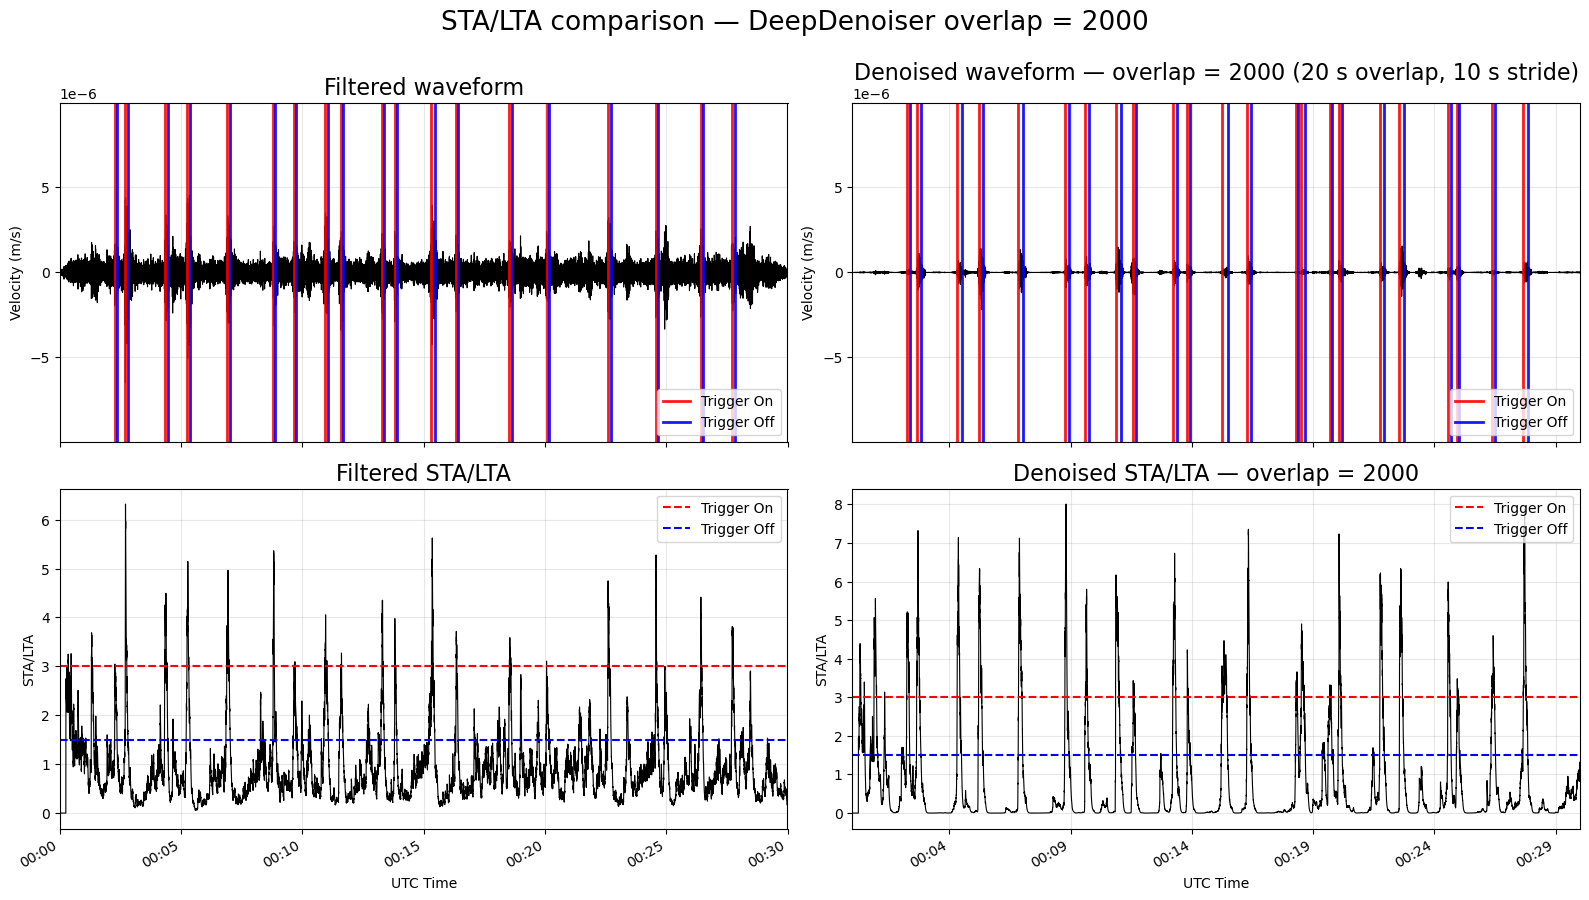

overlap=2500: 23 denoised events
    Any NaNs (denoised): False


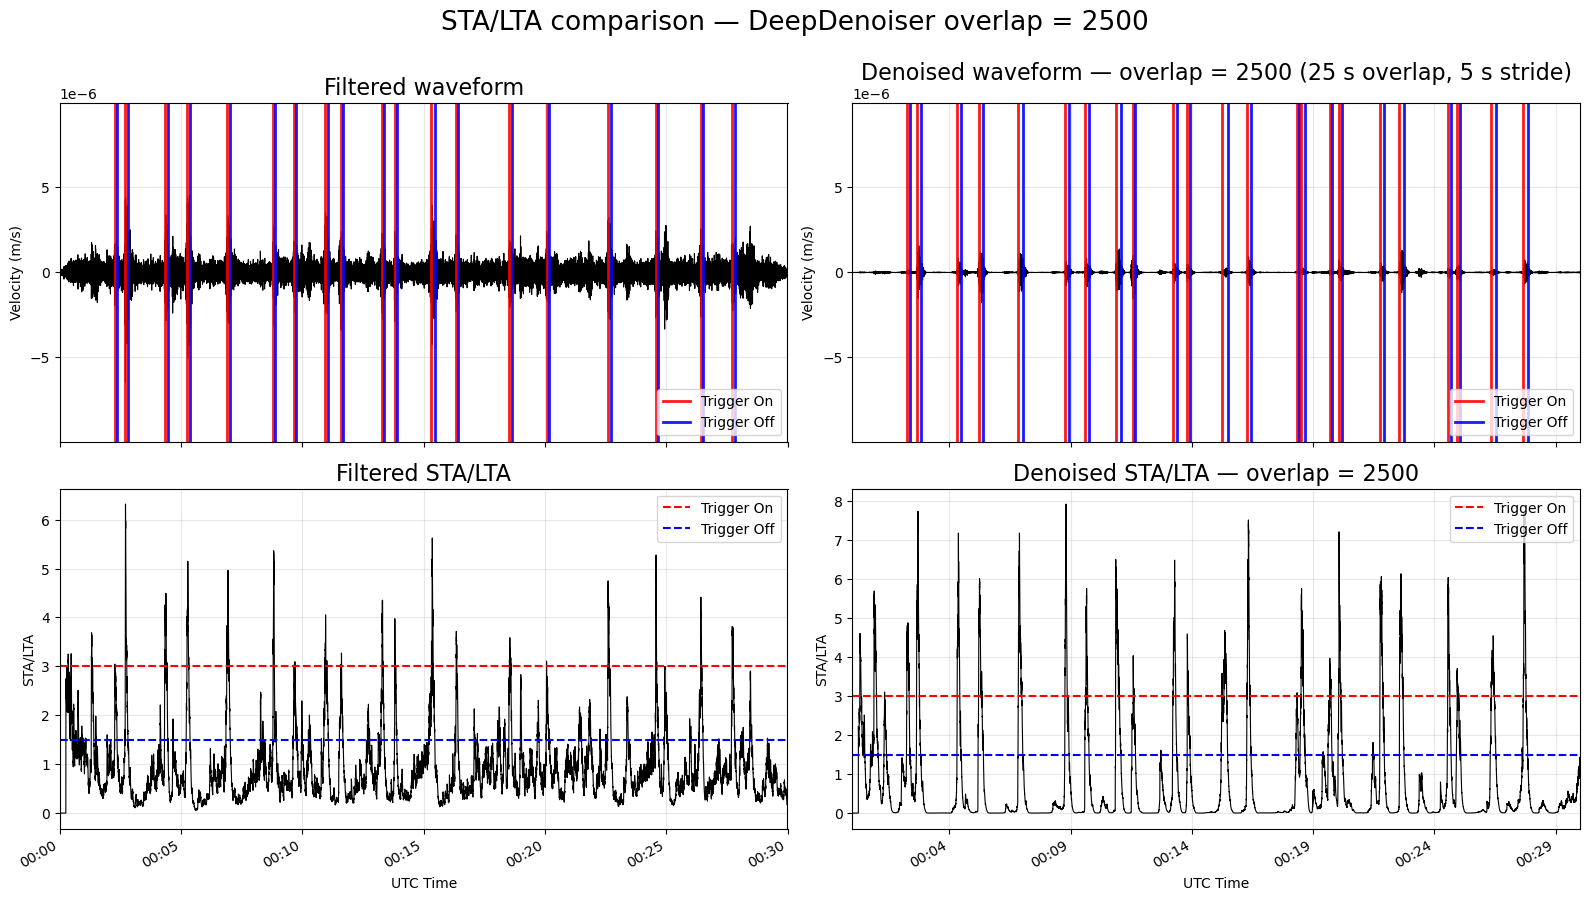

In [81]:
# %% STA/LTA comparison for each DeepDenoiser overlap
#
# For each overlap setting:
#   - Filtered waveform + STA/LTA triggers
#   - Denoised waveform + STA/LTA triggers
#   - Filtered STA/LTA characteristic function
#   - Denoised STA/LTA characteristic function
#
# Red vertical lines  = trigger ON
# Blue vertical lines = trigger OFF


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from obspy.signal.trigger import recursive_sta_lta, trigger_onset


# ============================================================
# STA/LTA settings
# ============================================================

# These should already be defined in your notebook.
# For example:
#
# STA_SECONDS = ...
# LTA_SECONDS = ...
# TRIGGER_ON = ...
# TRIGGER_OFF = ...
# STARTUP_SECONDS = ...


# ============================================================
# STA/LTA function
# ============================================================

def run_sta_lta(
    trace,
    sta_seconds=STA_SECONDS,
    lta_seconds=LTA_SECONDS,
    trigger_on=TRIGGER_ON,
    trigger_off=TRIGGER_OFF,
    startup_seconds=STARTUP_SECONDS
):

    fs = trace.stats.sampling_rate

    nsta = int(sta_seconds * fs)
    nlta = int(lta_seconds * fs)

    cft = recursive_sta_lta(
        trace.data,
        nsta,
        nlta
    )

    # No triggers during startup period
    startup_samples = int(
        startup_seconds * fs
    )

    cft_for_trigger = cft.copy()
    cft_for_trigger[:startup_samples] = 0

    triggers = trigger_onset(
        cft_for_trigger,
        trigger_on,
        trigger_off
    )

    return cft, triggers


# ============================================================
# Run STA/LTA on the filtered trace once
# ============================================================

cft_filtered, triggers_filtered = run_sta_lta(
    filtered_full_trace
)

print(
    f"Filtered: {len(triggers_filtered)} events"
)

print(
    f"Any NaNs (filtered): "
    f"{np.isnan(cft_filtered).any()}"
)


# ============================================================
# Store filtered times
# ============================================================

times_filtered = (
    filtered_full_trace.times(
        "matplotlib"
    )
)


# ============================================================
# Waveform plotting limits
# ============================================================

waveform_ylim = (
    -10e-6,
    10e-6
)

waveform_yticks = [
    -5e-6,
    0,
    5e-6
]


# ============================================================
# Run and plot each overlap
# ============================================================

for ov in overlaps:

    # --------------------------------------------------------
    # Get denoised trace for this overlap
    # --------------------------------------------------------

    denoised_trace = runs[ov]


    # --------------------------------------------------------
    # Run STA/LTA
    # --------------------------------------------------------

    cft_denoised, triggers_denoised = run_sta_lta(
        denoised_trace
    )


    # --------------------------------------------------------
    # Print event counts
    # --------------------------------------------------------

    print(
        f"overlap={ov}: "
        f"{len(triggers_denoised)} denoised events"
    )

    print(
        f"    Any NaNs (denoised): "
        f"{np.isnan(cft_denoised).any()}"
    )


    # --------------------------------------------------------
    # Denoised time axis
    # --------------------------------------------------------

    times_denoised = (
        denoised_trace.times(
            "matplotlib"
        )
    )


    # ========================================================
    # Create figure
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 9),
        sharex="col"
    )


    # ========================================================
    # 1. FILTERED WAVEFORM
    # ========================================================

    ax = axes[0, 0]

    ax.plot(
        times_filtered,
        filtered_full_trace.data,
        linewidth=0.8,
        color="black"
    )

    ax.set_title(
        "Filtered waveform",
        fontsize=16
    )

    ax.set_ylabel(
        "Velocity (m/s)"
    )

    ax.set_ylim(
        waveform_ylim
    )

    ax.set_yticks(
        waveform_yticks
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-6, -6)
    )


    # Trigger lines
    for i, (on, off) in enumerate(
        triggers_filtered
    ):

        ax.axvline(
            times_filtered[on],
            color="red",
            linewidth=2,
            alpha=0.9,
            label="Trigger On" if i == 0 else None
        )

        ax.axvline(
            times_filtered[off],
            color="blue",
            linewidth=2,
            alpha=0.9,
            label="Trigger Off" if i == 0 else None
        )


    ax.legend(
        loc="lower right"
    )

    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # 2. DENOISED WAVEFORM
    # ========================================================

    ax = axes[0, 1]

    ax.plot(
        times_denoised,
        denoised_trace.data,
        linewidth=0.8,
        color="black"
    )

    ax.set_title(
        f"Denoised waveform — "
        f"overlap = {ov} "
        f"({ov / model_fs:.0f} s overlap, "
        f"{(in_samples - ov) / model_fs:.0f} s stride)",
        fontsize=16
    )

    ax.set_ylabel(
        "Velocity (m/s)"
    )

    ax.set_ylim(
        waveform_ylim
    )

    ax.set_yticks(
        waveform_yticks
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-6, -6)
    )


    # Trigger lines
    for i, (on, off) in enumerate(
        triggers_denoised
    ):

        ax.axvline(
            times_denoised[on],
            color="red",
            linewidth=2,
            alpha=0.9,
            label="Trigger On" if i == 0 else None
        )

        ax.axvline(
            times_denoised[off],
            color="blue",
            linewidth=2,
            alpha=0.9,
            label="Trigger Off" if i == 0 else None
        )


    ax.legend(
        loc="lower right"
    )

    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # 3. FILTERED STA/LTA
    # ========================================================

    ax = axes[1, 0]

    ax.plot(
        times_filtered,
        cft_filtered,
        linewidth=0.8,
        color="black"
    )

    ax.axhline(
        TRIGGER_ON,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Trigger On"
    )

    ax.axhline(
        TRIGGER_OFF,
        color="blue",
        linestyle="--",
        linewidth=1.5,
        label="Trigger Off"
    )

    ax.set_title(
        "Filtered STA/LTA",
        fontsize=16
    )

    ax.set_ylabel(
        "STA/LTA"
    )

    ax.set_xlabel(
        "UTC Time"
    )

    ax.legend(
        loc="upper right"
    )

    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # 4. DENOISED STA/LTA
    # ========================================================

    ax = axes[1, 1]

    ax.plot(
        times_denoised,
        cft_denoised,
        linewidth=0.8,
        color="black"
    )

    ax.axhline(
        TRIGGER_ON,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Trigger On"
    )

    ax.axhline(
        TRIGGER_OFF,
        color="blue",
        linestyle="--",
        linewidth=1.5,
        label="Trigger Off"
    )

    ax.set_title(
        f"Denoised STA/LTA — overlap = {ov}",
        fontsize=16
    )

    ax.set_ylabel(
        "STA/LTA"
    )

    ax.set_xlabel(
        "UTC Time"
    )

    ax.legend(
        loc="upper right"
    )

    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # Common formatting
    # ========================================================

    for ax in axes.flat:

        ax.margins(
            x=0
        )

        ax.xaxis.set_major_locator(
            mdates.MinuteLocator(
                interval=5
            )
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter(
                "%H:%M"
            )
        )


    # ========================================================
    # Figure title
    # ========================================================

    fig.suptitle(
        f"STA/LTA comparison — DeepDenoiser overlap = {ov}",
        fontsize=19,
        y=0.995
    )

    fig.autofmt_xdate()

    plt.tight_layout()

    plt.show()